In [1]:
import json
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

In [7]:
def extract_labels(data_list, label_field, is_ground_truth=True):
    """
    Flattens the nested JSON structure into a dictionary mapping ID -> Label.
    """
    extracted = {}
    
    for item in data_list:
        # Extract Post ID
        post_id = item.get("ID")
        
        # Ground truths use 'label', predictions use 'Overall_Document_Polarity'
        if post_id and label_field in item:
            # Lowercase and strip to ensure "Negative" and "negative" are matched properly
            extracted[post_id] = str(item[label_field]).lower().strip()
            
        # Extract Comment IDs
        # We check both "comment_id" and "ID" to be safe, depending on your schema
        for comment in item.get("Comments", []):
            comment_id = comment.get("comment_id", comment.get("ID"))
            if comment_id and label_field in comment:
                extracted[comment_id] = str(comment[label_field]).lower().strip()
                
    return extracted

In [8]:
# Resolve file locations (works from workspace root or from backend/utils)
GROUND_TRUTH_FILE = Path("data/processed/db_labelled.json")
PREDICTIONS_FILE = Path("data/results/classified_eval.json")

if not GROUND_TRUTH_FILE.exists() and Path("../../data/processed/db_labelled.json").exists():
    GROUND_TRUTH_FILE = Path("../../data/processed/db_labelled.json")

if not PREDICTIONS_FILE.exists() and Path("../../data/results/classified_eval.json").exists():
    PREDICTIONS_FILE = Path("../../data/results/classified_eval.json")

print(f"Ground truth file: {GROUND_TRUTH_FILE.resolve()}")
print(f"Predictions file: {PREDICTIONS_FILE.resolve()}")

if not GROUND_TRUTH_FILE.exists():
    raise FileNotFoundError(f"Ground truth file not found: {GROUND_TRUTH_FILE}")

if not PREDICTIONS_FILE.exists():
    raise FileNotFoundError(
        f"Predictions file not found yet: {PREDICTIONS_FILE}. "
        "Add classified_eval.json to data/results and rerun this cell."
    )

# 1. Load the JSON files
with open(GROUND_TRUTH_FILE, 'r', encoding='utf-8') as f:
    ground_truth_data = json.load(f)
    
with open(PREDICTIONS_FILE, 'r', encoding='utf-8') as f:
    predictions_data = json.load(f)

# 2. Extract the flattened dictionaries
gt_dict = extract_labels(ground_truth_data, label_field="label")
pred_dict = extract_labels(predictions_data, label_field="Overall_Document_Polarity")

# 3. Match the labels and FILTER out 'irrelevant'
y_true = []
y_pred = []
matched_ids = []
missing_ids = []
ignored_irrelevant = 0

for doc_id, true_label in gt_dict.items():
    if true_label == "irrelevant":
        ignored_irrelevant += 1
        continue # Skip to the next record
        
    if doc_id in pred_dict:
        y_true.append(true_label)
        y_pred.append(pred_dict[doc_id])
        matched_ids.append(doc_id)
    else:
        missing_ids.append(doc_id)

print(f"Total Ground Truth records: {len(gt_dict)}")
print(f"Ignored 'irrelevant' ground truths: {ignored_irrelevant}")
print(f"Successfully matched RELEVANT records: {len(y_true)}")
print(f"Ground truth records missing from predictions: {len(missing_ids)}")

Ground truth file: C:\Users\ryanc\Downloads\NTU Stuff\SC4021\SC4021-project\data\processed\db_labelled.json
Predictions file: C:\Users\ryanc\Downloads\NTU Stuff\SC4021\SC4021-project\data\results\classified_eval.json
Total Ground Truth records: 2166
Ignored 'irrelevant' ground truths: 534
Successfully matched RELEVANT records: 1599
Ground truth records missing from predictions: 33


In [9]:
# Removed 'irrelevant' from expected labels
expected_labels = ["positive", "negative", "neutral"]

# Generate the classification report
report = classification_report(
    y_true, 
    y_pred, 
    labels=expected_labels,
    target_names=[label.capitalize() for label in expected_labels],
    zero_division=0
)

print("--- Sentiment Pipeline Evaluation Report (Relevant Only) ---\n")
print(report)

--- Sentiment Pipeline Evaluation Report (Relevant Only) ---

              precision    recall  f1-score   support

    Positive       0.57      0.49      0.53       431
    Negative       0.69      0.60      0.64       529
     Neutral       0.54      0.65      0.59       639

    accuracy                           0.59      1599
   macro avg       0.60      0.58      0.59      1599
weighted avg       0.60      0.59      0.59      1599



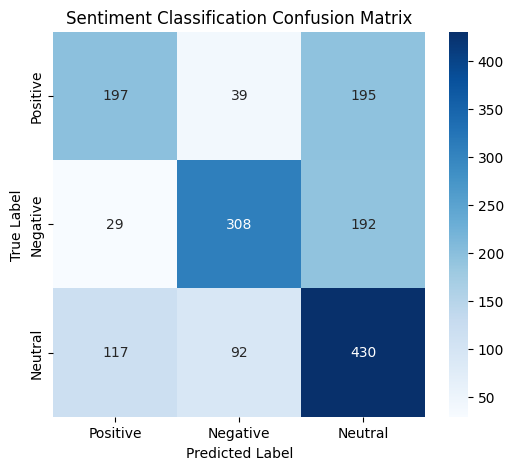

In [30]:
# Generate 3x3 confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=expected_labels)

# Plotting using seaborn
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, 
    annot=True, 
    fmt='d', 
    cmap='Blues',
    xticklabels=[l.capitalize() for l in expected_labels],
    yticklabels=[l.capitalize() for l in expected_labels]
)

plt.title('Sentiment Classification Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [15]:
# === Subjectivity Gate Diagnostic ===
# Paste this into a new cell AFTER the cell that builds y_true and y_pred
# (after the cell that loads gt_dict and pred_dict)

import json
from pathlib import Path

# Reload the raw files (already loaded as ground_truth_data and predictions_data)
# We need to cross-reference ground truth label vs predicted Subjectivity

subj_breakdown = {"subjective": {}, "objective": {}, "irrelevant": {}, "other": {}}

for item in ground_truth_data:
    post_id = item.get("ID")
    true_label = str(item.get("label", "")).lower().strip()
    if true_label == "irrelevant":
        continue  # skip irrelevant ground truths

    # Find matching prediction
    pred_item = next((p for p in predictions_data if p.get("ID") == post_id), None)
    if pred_item is None:
        continue

    subjectivity = str(pred_item.get("Subjectivity", "other")).lower().strip()
    key = subjectivity if subjectivity in subj_breakdown else "other"

    if true_label not in subj_breakdown[key]:
        subj_breakdown[key][true_label] = 0
    subj_breakdown[key][true_label] += 1

    # Also check comments
    for comment in item.get("Comments", []):
        comment_id = comment.get("comment_id", comment.get("ID"))
        true_c_label = str(comment.get("label", "")).lower().strip()
        if true_c_label == "irrelevant":
            continue

        pred_comment = next(
            (c for p in predictions_data for c in p.get("Comments", [])
             if c.get("comment_id", c.get("ID")) == comment_id),
            None
        )
        if pred_comment is None:
            continue

        subjectivity_c = str(pred_comment.get("Subjectivity", "other")).lower().strip()
        key_c = subjectivity_c if subjectivity_c in subj_breakdown else "other"

        if true_c_label not in subj_breakdown[key_c]:
            subj_breakdown[key_c][true_c_label] = 0
        subj_breakdown[key_c][true_c_label] += 1

print("=== Subjectivity Gate Diagnostic ===")
print("Shows how many TRUE positive/negative/neutral records are")
print("being assigned each subjectivity label by your detector.\n")

for subj_label, counts in subj_breakdown.items():
    total = sum(counts.values())
    if total == 0:
        continue
    print(f"Subjectivity='{subj_label}' ({total} records):")
    for true_label, count in sorted(counts.items()):
        print(f"  True label '{true_label}': {count}")
    print()

=== Subjectivity Gate Diagnostic ===
Shows how many TRUE positive/negative/neutral records are
being assigned each subjectivity label by your detector.

Subjectivity='subjective' (307 records):
  True label 'negative': 84
  True label 'neutral': 129
  True label 'positive': 94

Subjectivity='objective' (73 records):
  True label 'negative': 30
  True label 'neutral': 31
  True label 'positive': 12

Subjectivity='irrelevant' (145 records):
  True label 'negative': 52
  True label 'neutral': 54
  True label 'positive': 39



In [10]:
from collections import Counter

errors = [(t, p) for t, p in zip(y_true, y_pred) if t != p]
print("Most common error pairs (true → predicted):")
for pair, count in Counter(errors).most_common(10):
    print(f"  {pair[0]} → {pair[1]}: {count}")

Most common error pairs (true → predicted):
  negative → neutral: 177
  positive → neutral: 177
  neutral → positive: 124
  neutral → negative: 100
  positive → negative: 41
  negative → positive: 34
